# STOmics <-> Visium HD component matching via phase correlation

Standalone exploration (not wired into `ST.ipynb`'s Part 2) of a different
matching strategy: rather than assuming a 1:1 correspondence between
components (some tissue fragments that are one connected piece in Visium HD
come out as several disconnected components in STOmics, so 1:1 component
matching -- what `ST.ipynb` currently does via Hungarian assignment -- is
the wrong model), **locate each STOmics component's position within the
entire Visium HD counts image** instead. No assumption about how many
Visium components (or fractions of components) a STOmics fragment
corresponds to.

Method, per patient pair (`Pat{i}` <-> `Patient_{i}`, see `ST.ipynb`'s Part 2
for how that correspondence was confirmed):

1. **Candidate rotations** (`recover_rotation`): Visium and STOmics grids
   don't share a fixed axis convention (confirmed empirically elsewhere in
   this repo, see `border_sanity_checks.ipynb`), so this generates candidate
   rotations aligning the *whole* STOmics counts canvas onto the *whole*
   Visium counts canvas, via `skimage.transform.warp_polar` (`scaling="linear"`,
   not log-polar) on each canvas's FFT magnitude spectrum, then
   `skimage.registration.phase_cross_correlation` on the two polar-warped
   spectra -- rotation-in-image-space becomes a pure angular shift in
   polar-magnitude-spectrum space (the "Fourier-Mellin" rotation step).
   Scale is *not* estimated this way -- it's already known exactly from
   `bin_size_um` (8um Visium vs. 10um STOmics), so the STOmics canvas is
   rescaled by that exact ratio before this step. Magnitude spectra are
   symmetric under 180-degree rotation (Friedel symmetry), so this only
   recovers each candidate mod 180; reflections aren't rotations at all
   either, so both the canvas and its mirror get a candidate. Net: 2 flips x
   {angle, angle+180} = 4 orientation candidates, none picked yet.

2. **Resolve orientation once per patient** (`resolve_orientation`): tries
   all 4 candidates against the WHOLE STOmics canvas (not a single small
   component) and keeps whichever gives the best real-space Pearson
   correlation at its recovered position. A big, content-rich image gives a
   much better-conditioned estimate than any small fragment -- confirmed
   empirically, not just assumed: letting each component resolve its own
   orientation independently (an earlier version of this notebook) split
   one real patient's components between two genuinely different rotation
   estimates 32 degrees apart, which can't both be right, and produced
   visibly bad per-component alignments.

3. **Per-component localization** (`locate_component`): each component is
   rescaled (same known ratio) and rotated/reflected by the ONE orientation
   resolved in step 2 (fixed, not re-decided), zero-padded to the Visium
   canvas's shape, and located via *masked* phase correlation
   (`phase_cross_correlation` with `moving_mask`) -- translation only. The
   zero-padding is not a real measurement, so it's masked out rather than
   treated as legitimate zero-count background (unlike the Visium canvas's
   own zero-count background, which *is* real and stays unmasked). Match
   quality is a locally-computed Pearson correlation between the canvas at
   the recovered position and the component's own real pixels (masked
   phase correlation doesn't return a usable `error` -- skimage returns NaN
   there).


In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.lines import Line2D
from matplotlib.patches import Rectangle
from skimage.registration import phase_cross_correlation
from skimage.transform import rescale, rotate, warp_polar

sys.path.append("../../src/utils/")
import visium_hd
from border_fit import ALL_SAMPLES, get_grid_components

plt.rcParams['svg.fonttype'] = 'none'


/home/woody/iwbn/iwbn007h/bosperrus/truncated_graphs/.pixi/envs/default/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/woody/iwbn/iwbn007h/bosperrus/truncated_graphs/.pixi/envs/default/lib/python3.12/site-packages/pyproj/network.py:59: UserWarning: pyproj unable to set PROJ database path.
  _set_context_ca_bundle_path(ca_bundle_path)


In [2]:
PATIENT_PAIRS = [
    ("Pat1", "A02991D1"), ("Pat2", "A02994C6"), ("Pat3", "Y01087DD"), ("Pat4", "Y01084J8"),
]


def full_sample_raster(name):
    """Rasterize a sample's entire n_counts onto its native grid (all
    components combined, gaps filled with 0) -- the whole canvas to search
    within (Visium) or align (STOmics), not just one component."""
    row = ALL_SAMPLES.set_index("name").loc[name]
    n_counts, array_row, array_col, _ = visium_hd.load_counts_and_coords(row["loader"], row["h5ad_path"])
    grid, row_offset, col_offset = visium_hd.rasterize_grid(array_row, array_col, n_counts, fill=0.0)
    return grid, row_offset, col_offset, float(row["bin_size_um"])


def component_raster(name, component_rank):
    """Rasterize just one connected component's n_counts, tightly cropped
    to its own bounding box."""
    row = ALL_SAMPLES.set_index("name").loc[name]
    n_counts, array_row, array_col, _ = visium_hd.load_counts_and_coords(row["loader"], row["h5ad_path"])
    for rank, member_mask, size in get_grid_components(array_row, array_col):
        if rank == component_rank:
            grid, row_offset, col_offset = visium_hd.rasterize_grid(
                array_row[member_mask], array_col[member_mask], n_counts[member_mask], fill=0.0,
            )
            return grid, row_offset, col_offset, size
    raise ValueError(f"no component ranked {component_rank} for {name}")


## Stage 1: global rotation


In [3]:
def _pad_to_common_shape(a, b):
    """Zero-pad two arrays (top-left aligned) to their shared bounding
    shape, so their FFTs share the same frequency-bin resolution."""
    shape = (max(a.shape[0], b.shape[0]), max(a.shape[1], b.shape[1]))
    a_pad = np.zeros(shape)
    a_pad[:a.shape[0], :a.shape[1]] = a
    b_pad = np.zeros(shape)
    b_pad[:b.shape[0], :b.shape[1]] = b
    return a_pad, b_pad


def _magnitude_spectrum(img):
    return np.abs(np.fft.fftshift(np.fft.fft2(img)))


def recover_rotation(reference_img, moving_img, n_angles=360):
    """Candidate rotation angle (degrees, mod 180 -- Friedel symmetry, see
    module docstring) for EACH of moving_img's two possible reflections, via
    polar-warped FFT-magnitude phase correlation.

    Does NOT pick a winning flip here. Confirmed empirically (synthetic
    test: a correct-hypothesis case and a deliberately-wrong one both came
    back error=1.0000) that phase-normalized cross-correlation's own
    `error` does not discriminate a correct orientation hypothesis from an
    incorrect one for this kind of sparse, mostly-background image -- even
    though the *angle* it recovers is accurate (38 deg vs. a true 37 deg in
    that same test). So both flip hypotheses' angles are returned, and the
    real disambiguation (flip AND the mod-180 ambiguity) happens downstream
    in locate_component via real-space Pearson correlation, which does
    discriminate.

    Returns {False: angle_degrees, True: angle_degrees}, keyed by flipped.
    """
    ref_pad, mov_pad = _pad_to_common_shape(reference_img, moving_img)
    ref_spec = _magnitude_spectrum(ref_pad)
    radius = min(ref_spec.shape) // 2
    ref_polar = warp_polar(ref_spec, scaling="linear", radius=radius, output_shape=(n_angles, radius))

    angles = {}
    for flipped in (False, True):
        candidate = np.fliplr(mov_pad) if flipped else mov_pad
        mov_spec = _magnitude_spectrum(candidate)
        mov_polar = warp_polar(mov_spec, scaling="linear", radius=radius, output_shape=(n_angles, radius))

        shift, _, _ = phase_cross_correlation(ref_polar, mov_polar, normalization="phase")
        angles[flipped] = (float(shift[0]) * 360.0 / n_angles) % 180.0
    return angles


## Stage 2: per-component localization (masked phase correlation)


In [4]:
def _local_pearson(canvas, placed_component, row_shift, col_shift):
    """Pearson correlation between the canvas region at the recovered shift
    and the (rotated) component's own real pixels, restricted to the
    component's own footprint -- an interpretable match-quality score, since
    masked phase_cross_correlation itself returns NaN for `error`."""
    h, w = placed_component.shape
    r0, c0 = int(round(row_shift)), int(round(col_shift))
    canvas_h, canvas_w = canvas.shape
    rs, re = max(r0, 0), min(r0 + h, canvas_h)
    cs, ce = max(c0, 0), min(c0 + w, canvas_w)
    if re <= rs or ce <= cs:
        return -np.inf
    canvas_crop = canvas[rs:re, cs:ce]
    comp_crop = placed_component[rs - r0: re - r0, cs - c0: ce - c0]
    mask = comp_crop > 0
    if mask.sum() < 10:
        return -np.inf
    return float(np.corrcoef(canvas_crop[mask], comp_crop[mask])[0, 1])


def _try_orientation(component_img, canvas_img, angle_deg, flipped):
    """Rotate/reflect component_img by one (flip, angle) candidate, zero-pad
    it to a shape big enough to hold both it and the canvas, and locate its
    best-matching position via masked phase correlation -- the padded
    region isn't real data, so it's masked out rather than treated as a
    genuine zero measurement (unlike the canvas's own zero-count background,
    which is real and stays unmasked).

    A rotated (resize=True) component can end up LARGER than canvas_img in
    either dimension (bounding-box growth is close to sqrt(2)x for a
    component near a 45-degree angle) -- the padded search space is sized to
    fit whichever of the two is bigger, so this never breaks regardless of
    component/canvas size. Padding only ever extends the bottom/right edge
    (top-left aligned), so canvas_img's own origin -- and therefore the
    recovered shift -- stays directly interpretable in canvas_img's own
    original pixel coordinates, no offset correction needed.

    Returns dict with row/col position (top-left, in canvas_img's own pixel
    coordinates), the given angle/flip, and a match-quality score (Pearson
    correlation at the recovered position -- the only metric in this
    pipeline that actually discriminates a correct hypothesis from an
    incorrect one, see recover_rotation's docstring).
    """
    img = np.fliplr(component_img) if flipped else component_img
    rotated = rotate(img, angle_deg, resize=True, preserve_range=True)

    search_shape = (max(canvas_img.shape[0], rotated.shape[0]),
                     max(canvas_img.shape[1], rotated.shape[1]))
    canvas_padded = np.zeros(search_shape)
    canvas_padded[:canvas_img.shape[0], :canvas_img.shape[1]] = canvas_img
    comp_padded = np.zeros(search_shape)
    comp_padded[:rotated.shape[0], :rotated.shape[1]] = rotated
    comp_mask = comp_padded > 0

    shift, _, _ = phase_cross_correlation(
        canvas_padded, comp_padded,
        reference_mask=np.ones(search_shape, dtype=bool),
        moving_mask=comp_mask,
    )
    score = _local_pearson(canvas_padded, comp_padded, shift[0], shift[1])
    return {
        "row": float(shift[0]), "col": float(shift[1]),
        "angle": angle_deg, "flipped": flipped,
        "height": rotated.shape[0], "width": rotated.shape[1],
        "score": score,
    }


def resolve_orientation(component_img, canvas_img, angles_by_flip):
    """Try all 4 (flip, angle) candidates left over from recover_rotation
    (2 flips x {angle, angle+180}, the latter from Friedel symmetry's
    mod-180 ambiguity) and keep whichever gives the highest real-space
    Pearson correlation.

    Meant to be called ONCE PER PATIENT, on the whole (rescaled) STOmics
    canvas -- a big, content-rich image gives a much better-conditioned
    orientation estimate than any single small fragment. Confirmed
    empirically this isn't just theoretical: letting each component
    independently resolve its own orientation (an earlier version of this
    notebook) split one real patient's components between two genuinely
    different rotation estimates 32 degrees apart, which can't both be
    right, and produced visibly bad per-component alignments.
    """
    best = None
    for flipped, angle_deg in angles_by_flip.items():
        for extra in (0, 180):
            result = _try_orientation(component_img, canvas_img, angle_deg + extra, flipped)
            if best is None or result["score"] > best["score"]:
                best = result
    return best


def locate_component(component_img, canvas_img, angle_deg, flipped):
    """Translation-only localization at a FIXED, already-resolved
    orientation (see resolve_orientation, which should be called once per
    patient and its result reused here for every one of that patient's
    components)."""
    return _try_orientation(component_img, canvas_img, angle_deg, flipped)


In [5]:
def place_component(canvas_shape, component_img, angle_deg, flipped, row_shift, col_shift):
    """Reflect/rotate component_img by a locate_component result and place it
    into a canvas_shape-sized array at (row_shift, col_shift) -- clipped to
    canvas_shape's own bounds, since a component can legitimately extend
    partly outside the canvas (e.g. a fragment recovered near the tissue's
    own edge). Same coordinate convention as locate_component/_local_pearson,
    so this always lines up correctly with the canvas it was matched against.
    """
    img = np.fliplr(component_img) if flipped else component_img
    rotated = rotate(img, angle_deg, resize=True, preserve_range=True)

    placed = np.zeros(canvas_shape)
    r0, c0 = int(round(row_shift)), int(round(col_shift))
    h, w = rotated.shape

    src_r0, src_c0 = max(0, -r0), max(0, -c0)
    dst_r0, dst_c0 = max(0, r0), max(0, c0)
    dst_r1 = min(canvas_shape[0], r0 + h)
    dst_c1 = min(canvas_shape[1], c0 + w)
    src_r1 = src_r0 + (dst_r1 - dst_r0)
    src_c1 = src_c0 + (dst_c1 - dst_c0)

    if dst_r1 > dst_r0 and dst_c1 > dst_c0:
        placed[dst_r0:dst_r1, dst_c0:dst_c1] = rotated[src_r0:src_r1, src_c0:src_c1]
    return placed


def render_aligned_overlay(visium_canvas, stomics_name, located_df, scale, title=None, ax=None):
    """Overlay each located STOmics component's actual (rotated, rescaled,
    positioned) pixel footprint on the Visium canvas -- one distinct color
    per component, so alignment quality is judged from the real data, not
    just a bounding-box proxy."""
    own_fig = ax is None
    if own_fig:
        fig, ax = plt.subplots(figsize=(8, 8))
    background = np.log1p(visium_canvas)
    ax.imshow(background, cmap="gray", vmin=0, vmax=np.percentile(background, 99.5))

    cmap = plt.get_cmap("tab10")
    handles = []
    for i, (_, r) in enumerate(located_df.iterrows()):
        comp_img, _, _, _ = component_raster(stomics_name, int(r["stomics_component_rank"]))
        comp_img_rescaled = rescale(comp_img, scale, order=1, preserve_range=True, anti_aliasing=True)
        placed = place_component(visium_canvas.shape, comp_img_rescaled, r["angle"], r["flipped"], r["row"], r["col"])

        color = cmap(i % 10)
        rgba = np.zeros((*visium_canvas.shape, 4))
        mask = placed > 0
        rgba[mask, :3] = color[:3]
        rgba[mask, 3] = 0.6
        ax.imshow(rgba)
        handles.append(Line2D([0], [0], marker="s", color="none", markerfacecolor=color, markersize=10,
                               label=f"component {int(r['stomics_component_rank'])} (score={r['score']:.2f})"))

    ax.legend(handles=handles, loc="upper left", bbox_to_anchor=(1.0, 1.0), fontsize=8)
    ax.set_title(title or f"{stomics_name} components aligned onto Visium canvas")
    ax.axis("off")
    if own_fig:
        plt.tight_layout()
        plt.show()


## Demo on one patient (Pat3 / Y01087DD -- highest whole-sample similarity in `ST.ipynb`'s earlier NCC-based attempt)


In [6]:
visium_name, stomics_name = "Pat3", "Y01087DD"

visium_canvas, v_row0, v_col0, visium_bin_um = full_sample_raster(visium_name)
stomics_canvas, s_row0, s_col0, stomics_bin_um = full_sample_raster(stomics_name)

scale = stomics_bin_um / visium_bin_um
stomics_canvas_rescaled = rescale(stomics_canvas, scale, order=1, preserve_range=True, anti_aliasing=True)

angles = recover_rotation(visium_canvas, stomics_canvas_rescaled)
print(f"candidate rotations (mod 180): not-flipped={angles[False]:.1f} deg, flipped={angles[True]:.1f} deg")
print("(both are just candidates here -- which one's actually right is resolved by the real-space Pearson check below, not this step)")


candidate rotations (mod 180): not-flipped=0.0 deg, flipped=0.0 deg
(both are just candidates here -- which one's actually right is resolved by the real-space Pearson check below, not this step)


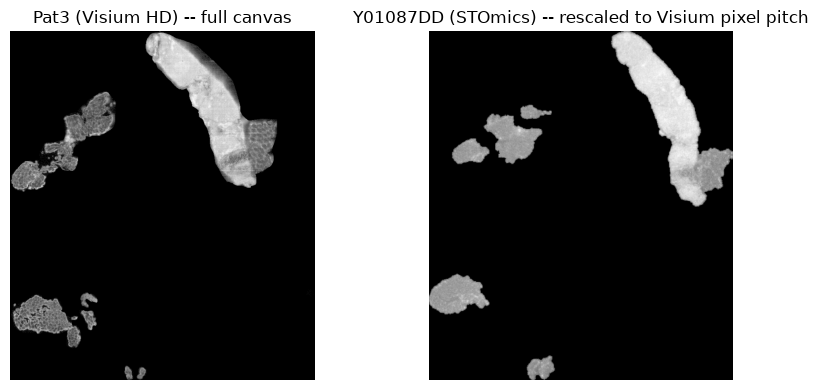

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(9, 4))
axes[0].imshow(np.log1p(visium_canvas), cmap="gray")
axes[0].set_title(f"{visium_name} (Visium HD) -- full canvas")
axes[0].axis("off")
axes[1].imshow(np.log1p(stomics_canvas_rescaled), cmap="gray")
axes[1].set_title(f"{stomics_name} (STOmics) -- rescaled to Visium pixel pitch")
axes[1].axis("off")
plt.tight_layout()
plt.show()


Sanity check: resolve the whole-canvas orientation the same way `locate_component`
resolves a component's (reuse it, treating the whole rescaled STOmics canvas
as one big "component"), then derotate/reflect by that and eyeball whether
it now visually resembles the Visium canvas's orientation -- a genuine check
on `warp_polar`/`phase_cross_correlation`'s sign conventions, not something
to take on faith.


resolved orientation: angle=0.0 deg, flipped=False, score=0.650


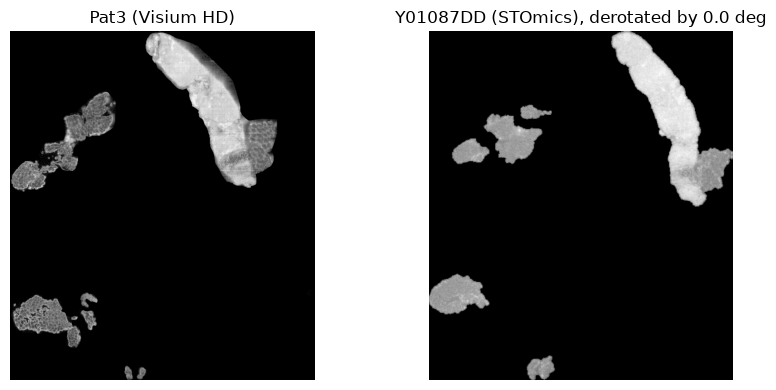

In [8]:
whole_canvas_result = resolve_orientation(stomics_canvas_rescaled, visium_canvas, angles)
print(f"resolved orientation: angle={whole_canvas_result['angle']:.1f} deg, "
      f"flipped={whole_canvas_result['flipped']}, score={whole_canvas_result['score']:.3f}")

aligned_whole = np.fliplr(stomics_canvas_rescaled) if whole_canvas_result["flipped"] else stomics_canvas_rescaled
aligned_whole = rotate(aligned_whole, whole_canvas_result["angle"], resize=True, preserve_range=True)

fig, axes = plt.subplots(1, 2, figsize=(9, 4))
axes[0].imshow(np.log1p(visium_canvas), cmap="gray")
axes[0].set_title(f"{visium_name} (Visium HD)")
axes[0].axis("off")
axes[1].imshow(np.log1p(aligned_whole), cmap="gray")
axes[1].set_title(f"{stomics_name} (STOmics), derotated by {whole_canvas_result['angle']:.1f} deg"
                   + (", flipped" if whole_canvas_result["flipped"] else ""))
axes[1].axis("off")
plt.tight_layout()
plt.show()


In [9]:
stomics_row = ALL_SAMPLES.set_index("name").loc[stomics_name]
n_counts, array_row, array_col, _ = visium_hd.load_counts_and_coords(stomics_row["loader"], stomics_row["h5ad_path"])
stomics_components = get_grid_components(array_row, array_col)
print(f"{stomics_name}: {len(stomics_components)} component(s)")

located = []
for rank, member_mask, size in stomics_components:
    comp_img, _, _, _ = component_raster(stomics_name, rank)
    comp_img_rescaled = rescale(comp_img, scale, order=1, preserve_range=True, anti_aliasing=True)
    result = locate_component(comp_img_rescaled, visium_canvas, whole_canvas_result["angle"], whole_canvas_result["flipped"])
    result.update(stomics_component_rank=rank, component_size=size)
    located.append(result)
    print(f"  component {rank} (n={size}): row={result['row']:.0f}, col={result['col']:.0f}, score={result['score']:.3f}")

located_df = pd.DataFrame(located)


Y01087DD: 5 component(s)
  component 0 (n=23587): row=64, col=369, score=0.517
  component 1 (n=5337): row=754, col=199, score=0.359
  component 2 (n=5295): row=214, col=58, score=0.587
  component 3 (n=2086): row=-28, col=298, score=0.401
  component 4 (n=1551): row=602, col=-25, score=0.376


Overlay each located STOmics component as a box on the Visium canvas,
colored by match score (Pearson correlation at the recovered position).


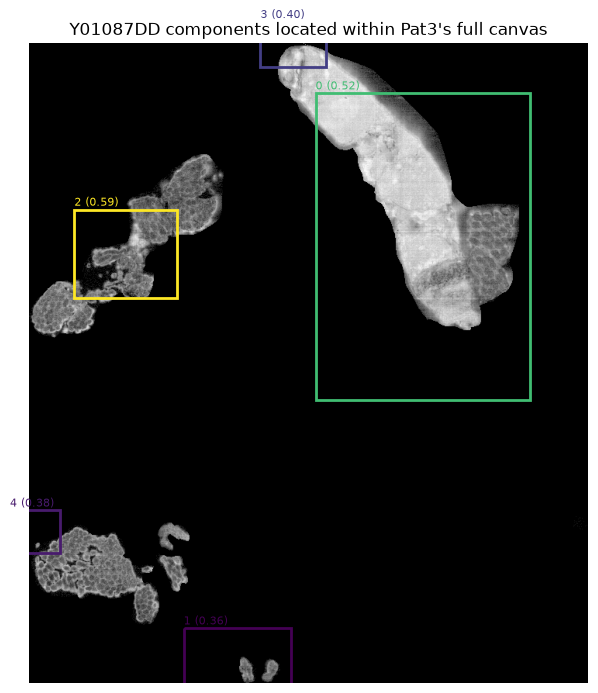

In [10]:
fig, ax = plt.subplots(figsize=(7, 7))
ax.imshow(np.log1p(visium_canvas), cmap="gray")

norm_scores = (located_df["score"] - located_df["score"].min()) / (located_df["score"].max() - located_df["score"].min() + 1e-9)
cmap = plt.get_cmap("viridis")
for _, r in located_df.iterrows():
    color = cmap(norm_scores[r.name])
    ax.add_patch(Rectangle((r["col"], r["row"]), r["width"], r["height"],
                            fill=False, edgecolor=color, linewidth=2))
    ax.text(r["col"], r["row"] - 5, f"{int(r['stomics_component_rank'])} ({r['score']:.2f})",
            color=color, fontsize=8)

ax.set_title(f"{stomics_name} components located within {visium_name}'s full canvas")
ax.axis("off")
plt.tight_layout()
plt.show()


Same thing, but with each component's actual (rotated, positioned) pixel
content overlaid -- not just a bounding box -- so alignment quality can be
judged directly from the real data.

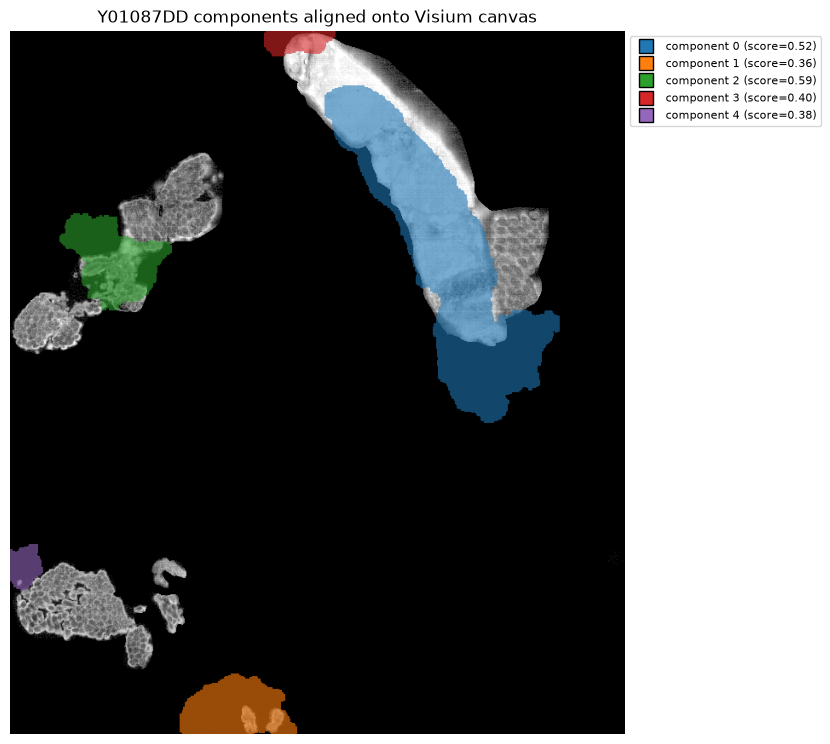

In [11]:
render_aligned_overlay(visium_canvas, stomics_name, located_df, scale)


## All 4 patient pairs


In [12]:
all_located = []
canvases = {}
scales = {}

for visium_name, stomics_name in PATIENT_PAIRS:
    visium_canvas, _, _, visium_bin_um = full_sample_raster(visium_name)
    stomics_canvas, _, _, stomics_bin_um = full_sample_raster(stomics_name)
    scale = stomics_bin_um / visium_bin_um
    stomics_canvas_rescaled = rescale(stomics_canvas, scale, order=1, preserve_range=True, anti_aliasing=True)

    angles = recover_rotation(visium_canvas, stomics_canvas_rescaled)
    whole_result = resolve_orientation(stomics_canvas_rescaled, visium_canvas, angles)
    print(f"{visium_name} <-> {stomics_name}: resolved angle={whole_result['angle']:.1f} deg, "
          f"flipped={whole_result['flipped']}, whole-canvas score={whole_result['score']:.3f}")
    canvases[visium_name] = visium_canvas
    scales[visium_name] = scale

    stomics_row = ALL_SAMPLES.set_index("name").loc[stomics_name]
    n_counts, array_row, array_col, _ = visium_hd.load_counts_and_coords(stomics_row["loader"], stomics_row["h5ad_path"])
    for rank, member_mask, size in get_grid_components(array_row, array_col):
        comp_img, _, _, _ = component_raster(stomics_name, rank)
        comp_img_rescaled = rescale(comp_img, scale, order=1, preserve_range=True, anti_aliasing=True)
        result = locate_component(comp_img_rescaled, visium_canvas, whole_result["angle"], whole_result["flipped"])
        result.update(visium_sample=visium_name, stomics_sample=stomics_name,
                       stomics_component_rank=rank, component_size=size)
        all_located.append(result)

all_located_df = pd.DataFrame(all_located)
all_located_df[["visium_sample", "stomics_sample", "stomics_component_rank", "component_size", "row", "col", "angle", "flipped", "score"]]


Pat1 <-> A02991D1: resolved angle=343.0 deg, flipped=False, whole-canvas score=0.376
Pat2 <-> A02994C6: resolved angle=270.0 deg, flipped=True, whole-canvas score=0.471
Pat3 <-> Y01087DD: resolved angle=0.0 deg, flipped=False, whole-canvas score=0.650
Pat4 <-> Y01084J8: resolved angle=200.0 deg, flipped=False, whole-canvas score=0.516


,visium_sample,stomics_sample,stomics_component_rank,component_size,row,col,angle,flipped,score
0,Pat1,A02991D1,0,81530,-132.0,155.0,343.0,False,0.376110
1,Pat2,A02994C6,0,17216,149.0,612.0,270.0,True,0.491551
2,Pat2,A02994C6,1,11808,436.0,256.0,270.0,True,0.476234
3,Pat2,A02994C6,2,10213,441.0,287.0,270.0,True,0.407908
4,Pat2,A02994C6,3,9867,106.0,680.0,270.0,True,0.407785
5,Pat2,A02994C6,4,6538,549.0,431.0,270.0,True,0.466959
6,Pat3,Y01087DD,0,23587,64.0,369.0,0.0,False,0.517466
7,Pat3,Y01087DD,1,5337,754.0,199.0,0.0,False,0.359494
8,Pat3,Y01087DD,2,5295,214.0,58.0,0.0,False,0.586712
9,Pat3,Y01087DD,3,2086,-28.0,298.0,0.0,False,0.400831


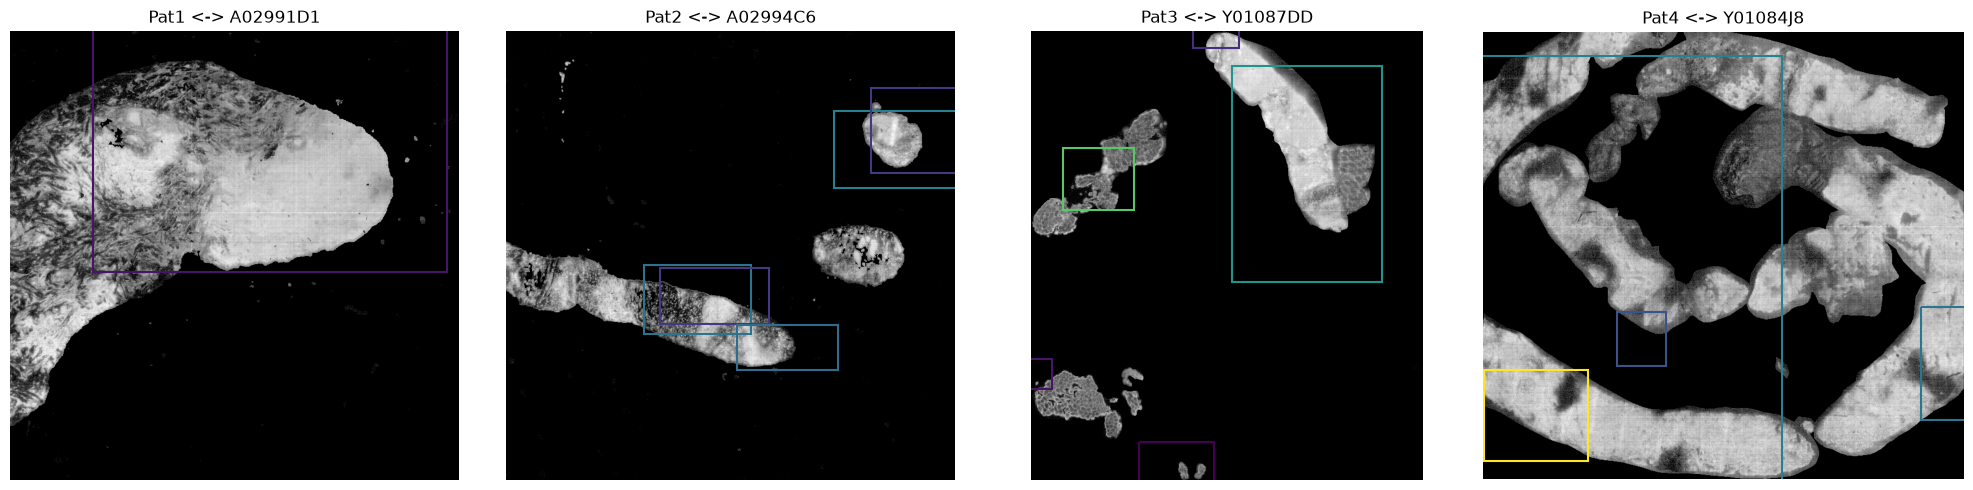

In [13]:
fig, axes = plt.subplots(1, 4, figsize=(20, 5))
for ax, (visium_name, stomics_name) in zip(axes, PATIENT_PAIRS):
    ax.imshow(np.log1p(canvases[visium_name]), cmap="gray")
    subset = all_located_df[all_located_df["visium_sample"] == visium_name]
    norm_scores = (subset["score"] - all_located_df["score"].min()) / (all_located_df["score"].max() - all_located_df["score"].min() + 1e-9)
    cmap = plt.get_cmap("viridis")
    for (_, r), s in zip(subset.iterrows(), norm_scores):
        color = cmap(s)
        ax.add_patch(Rectangle((r["col"], r["row"]), r["width"], r["height"],
                                fill=False, edgecolor=color, linewidth=1.5))
    ax.set_title(f"{visium_name} <-> {stomics_name}")
    ax.axis("off")
plt.tight_layout()
plt.show()


Same, with each component's actual aligned pixel content instead of just a bounding box.

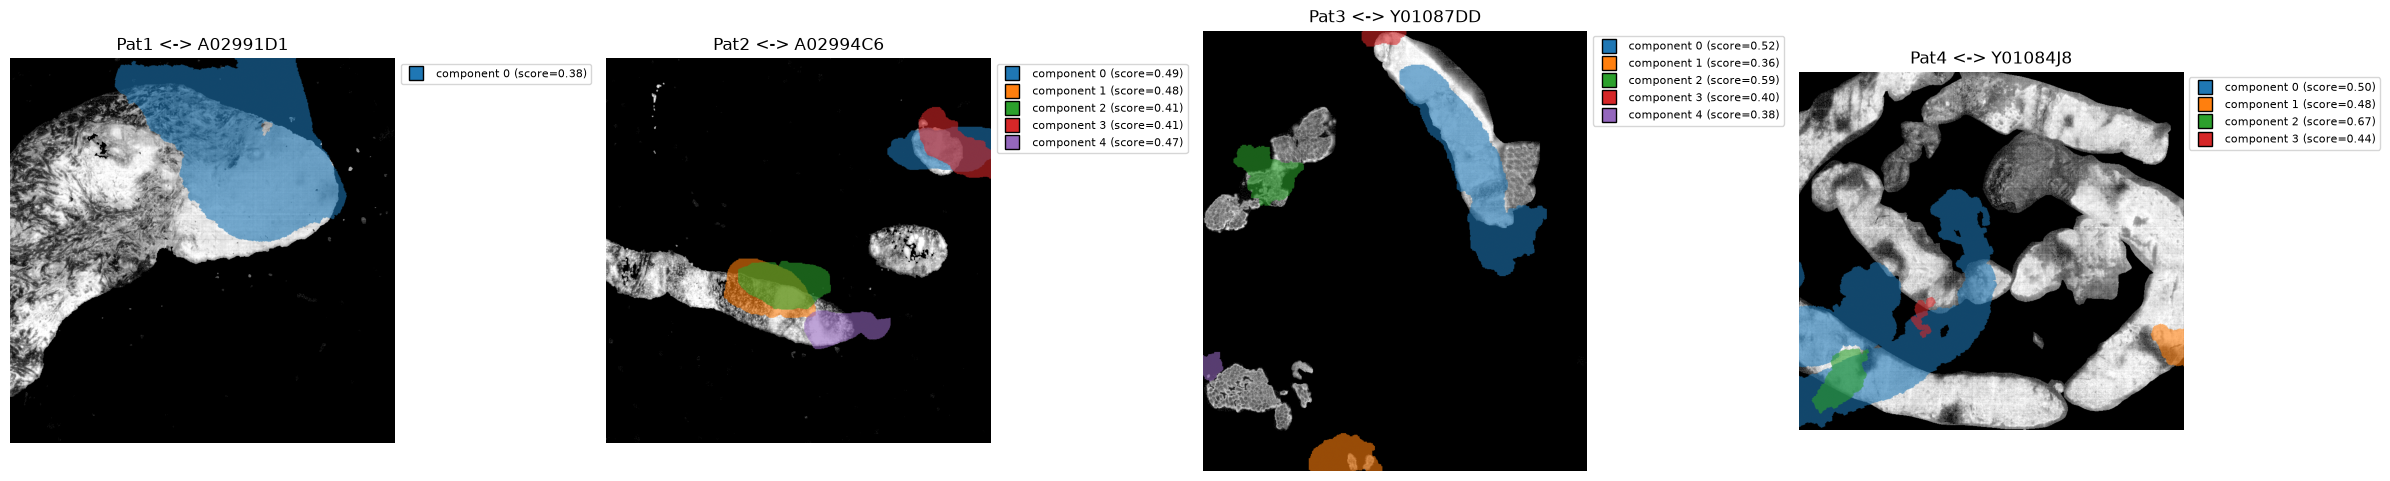

In [14]:
fig, axes = plt.subplots(1, 4, figsize=(24, 6))
for ax, (visium_name, stomics_name) in zip(axes, PATIENT_PAIRS):
    subset = all_located_df[all_located_df["visium_sample"] == visium_name]
    render_aligned_overlay(canvases[visium_name], stomics_name, subset, scales[visium_name],
                            title=f"{visium_name} <-> {stomics_name}", ax=ax)
plt.tight_layout()
plt.show()


## Alternative: shape/outline-only matching (binary tissue mask, not raw counts)

Domain feedback: samples 1, 3, 4 should be easily matchable even from mask
outlines alone -- sample 2 is genuinely hard. Everything above matches on
each platform's raw `n_counts`, whose fine internal texture differs a lot
between chemistries (Visium vs. STOmics) even on the same physical tissue --
plausibly adding noise the "easy" samples didn't need, Pat1 in particular
(score 0.376, worst of the 4, despite being a single simple blob). This
reruns the *identical* pipeline (`recover_rotation` -> `resolve_orientation`
-> `locate_component` -- no changes to any of that logic) on a
lightly-blurred binary "is there tissue here" mask instead, isolating
shape/outline correspondence from platform-specific texture.

In [15]:
from scipy.ndimage import gaussian_filter


def to_mask(canvas, sigma=3):
    """Binary tissue-presence mask, lightly blurred -- shape/outline only,
    not the platform-specific texture inside the tissue. sigma=3 (pixels,
    at Visium's 8um pitch) smooths jagged single-pixel mask edges into
    something less spiky for the FFT-based rotation step, without erasing
    genuine shape information."""
    return gaussian_filter((canvas > 0).astype(float), sigma=sigma)


mask_located = []
mask_canvases = {}
mask_scales = {}

for visium_name, stomics_name in PATIENT_PAIRS:
    visium_canvas, _, _, visium_bin_um = full_sample_raster(visium_name)
    stomics_canvas, _, _, stomics_bin_um = full_sample_raster(stomics_name)
    scale = stomics_bin_um / visium_bin_um
    stomics_canvas_rescaled = rescale(stomics_canvas, scale, order=1, preserve_range=True, anti_aliasing=True)

    visium_mask = to_mask(visium_canvas)
    stomics_mask = to_mask(stomics_canvas_rescaled)

    angles = recover_rotation(visium_mask, stomics_mask)
    whole_result = resolve_orientation(stomics_mask, visium_mask, angles)
    print(f"{visium_name} <-> {stomics_name}: resolved angle={whole_result['angle']:.1f} deg, "
          f"flipped={whole_result['flipped']}, whole-canvas (mask) score={whole_result['score']:.3f}")
    mask_canvases[visium_name] = visium_canvas
    mask_scales[visium_name] = scale

    stomics_row = ALL_SAMPLES.set_index("name").loc[stomics_name]
    n_counts, array_row, array_col, _ = visium_hd.load_counts_and_coords(stomics_row["loader"], stomics_row["h5ad_path"])
    for rank, member_mask, size in get_grid_components(array_row, array_col):
        comp_img, _, _, _ = component_raster(stomics_name, rank)
        comp_img_rescaled = rescale(comp_img, scale, order=1, preserve_range=True, anti_aliasing=True)
        comp_mask = to_mask(comp_img_rescaled)
        result = locate_component(comp_mask, visium_mask, whole_result["angle"], whole_result["flipped"])
        result.update(visium_sample=visium_name, stomics_sample=stomics_name,
                       stomics_component_rank=rank, component_size=size)
        mask_located.append(result)

mask_located_df = pd.DataFrame(mask_located)
mask_located_df[["visium_sample", "stomics_sample", "stomics_component_rank", "component_size", "row", "col", "angle", "flipped", "score"]]


Pat1 <-> A02991D1: resolved angle=180.0 deg, flipped=True, whole-canvas (mask) score=0.626
Pat2 <-> A02994C6: resolved angle=0.0 deg, flipped=False, whole-canvas (mask) score=0.453
Pat3 <-> Y01087DD: resolved angle=153.0 deg, flipped=False, whole-canvas (mask) score=0.391
Pat4 <-> Y01084J8: resolved angle=124.0 deg, flipped=False, whole-canvas (mask) score=0.339


,visium_sample,stomics_sample,stomics_component_rank,component_size,row,col,angle,flipped,score
0,Pat1,A02991D1,0,81530,333.0,-352.0,180.0,True,0.625861
1,Pat2,A02994C6,0,17216,306.0,-107.0,0.0,False,0.447977
2,Pat2,A02994C6,1,11808,327.0,-84.0,0.0,False,0.572061
3,Pat2,A02994C6,2,10213,91.0,669.0,0.0,False,0.455508
4,Pat2,A02994C6,3,9867,286.0,-93.0,0.0,False,0.771683
5,Pat2,A02994C6,4,6538,47.0,657.0,0.0,False,0.417192
6,Pat3,Y01087DD,0,23587,-317.0,160.0,153.0,False,0.393206
7,Pat3,Y01087DD,1,5337,599.0,-20.0,153.0,False,0.712414
8,Pat3,Y01087DD,2,5295,-101.0,263.0,153.0,False,0.629708
9,Pat3,Y01087DD,3,2086,182.0,112.0,153.0,False,0.802251


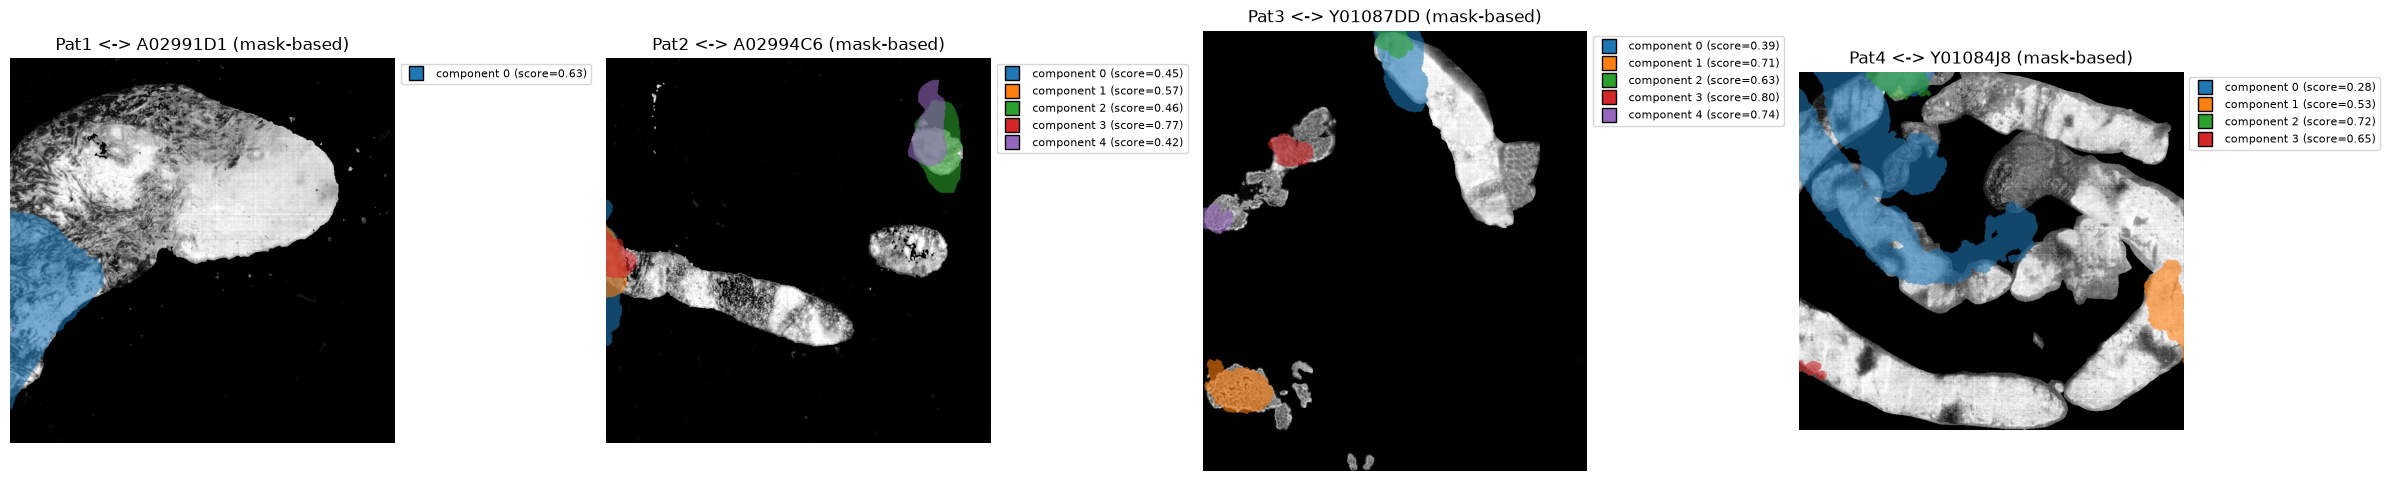

In [16]:
fig, axes = plt.subplots(1, 4, figsize=(24, 6))
for ax, (visium_name, stomics_name) in zip(axes, PATIENT_PAIRS):
    subset = mask_located_df[mask_located_df["visium_sample"] == visium_name]
    render_aligned_overlay(mask_canvases[visium_name], stomics_name, subset, mask_scales[visium_name],
                            title=f"{visium_name} <-> {stomics_name} (mask-based)", ax=ax)
plt.tight_layout()
plt.show()
